In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [37]:
df= pd.read_csv('/Users/jayprajapati/Documents/csv_files/Customer_Churn_Explained Ai/csv File/Churn_Modelling.xls')

In [38]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [40]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [41]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [42]:
df.value_counts('Surname')

Surname
Smith         32
Martin        29
Scott         29
Walker        28
Brown         26
              ..
Etheridge      1
Milliner       1
Milligan       1
Eva            1
Kuykendall     1
Name: count, Length: 2932, dtype: int64

In [43]:
df.drop('Surname',axis=1,inplace=True)

In [44]:
df.drop('RowNumber', axis=1, inplace=True)

In [45]:
df.drop('CustomerId', axis=1, inplace=True)

In [46]:
for i in df.columns:
    print(i)
    print(df[i].value_counts())

CreditScore
CreditScore
850    233
678     63
655     54
705     53
667     53
      ... 
404      1
351      1
365      1
417      1
419      1
Name: count, Length: 460, dtype: int64
Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Age
Age
37    478
38    477
35    474
36    456
34    447
     ... 
92      2
82      1
88      1
85      1
83      1
Name: count, Length: 70, dtype: int64
Tenure
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
Balance
Balance
0.00         3617
130170.82       2
105473.74       2
85304.27        1
159397.75       1
             ... 
81556.89        1
112687.69       1
108698.96       1
238387.56       1
130142.79       1
Name: count, Length: 6382, dtype: int64
NumOfProducts
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, 

<Axes: xlabel='CreditScore', ylabel='Count'>

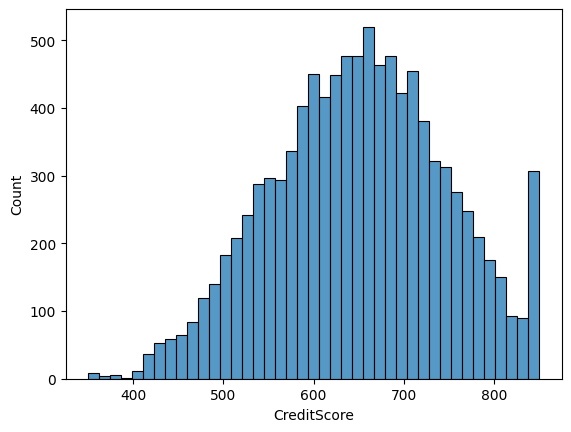

In [47]:
sns.histplot(df['CreditScore'])

In [48]:
df.value_counts('Gender')

Gender
Male      5457
Female    4543
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

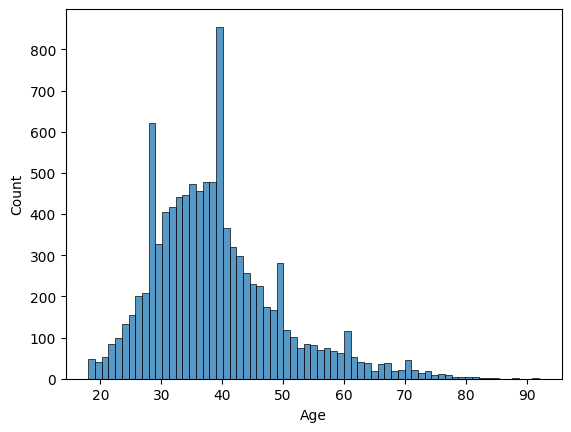

In [49]:
sns.histplot(df['Age'])

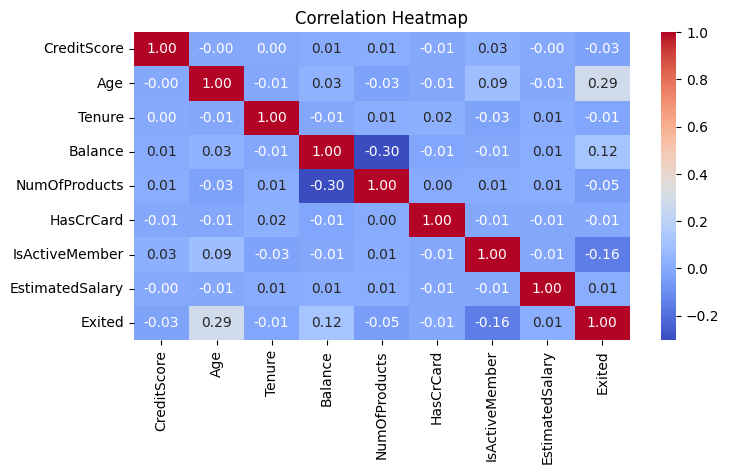

In [50]:
numerical_fetures = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical_fetures.corr()

# Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [51]:
from sklearn.preprocessing import LabelEncoder

geo_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

df['Geography'] = geo_encoder.fit_transform(df['Geography'])

df['Gender'] = gender_encoder.fit_transform(df['Gender'])


In [52]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


In [54]:
X= df.drop('Exited', axis=1)
y= df['Exited']

In [55]:
df.shape

(10000, 11)

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=  train_test_split(X,y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 10)
(2000, 10)
(8000,)
(2000,)


In [57]:
from xgboost import XGBClassifier
model= XGBClassifier()
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [58]:
y_pred= model.predict(X_test)

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.70      0.51      0.59       393

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000

[[1523   84]
 [ 194  199]]


In [60]:
train = model.score(X_train, y_train)
test = model.score(X_test, y_test)
print(train)
print(test)

0.955375
0.861


In [61]:
import shap


In [62]:
explainer= shap.TreeExplainer(model)


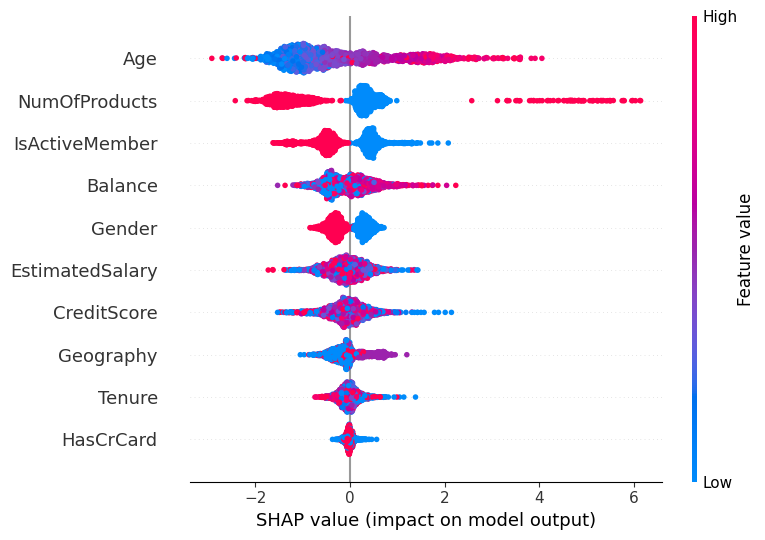

In [63]:
shape_values= explainer.shap_values(X_test)
shap.summary_plot(shape_values, X_test)

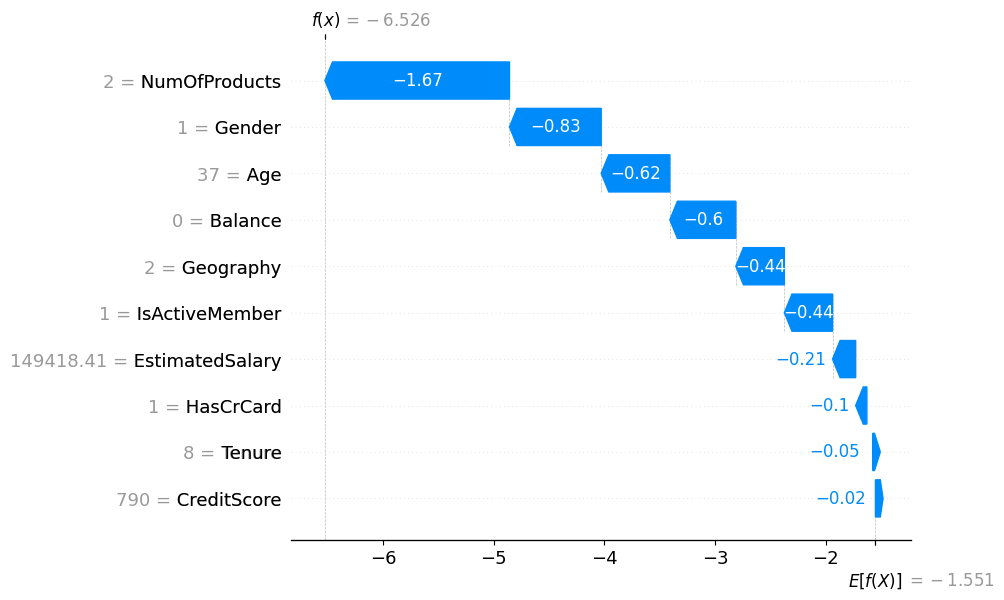

In [64]:
shap_values = explainer(X_test)
customer_index = 5

# 3. Generate a Waterfall Plot for this individual
shap.plots.waterfall(shap_values[customer_index])

Churn Probability: 31.6%
Predicted Label: Stay


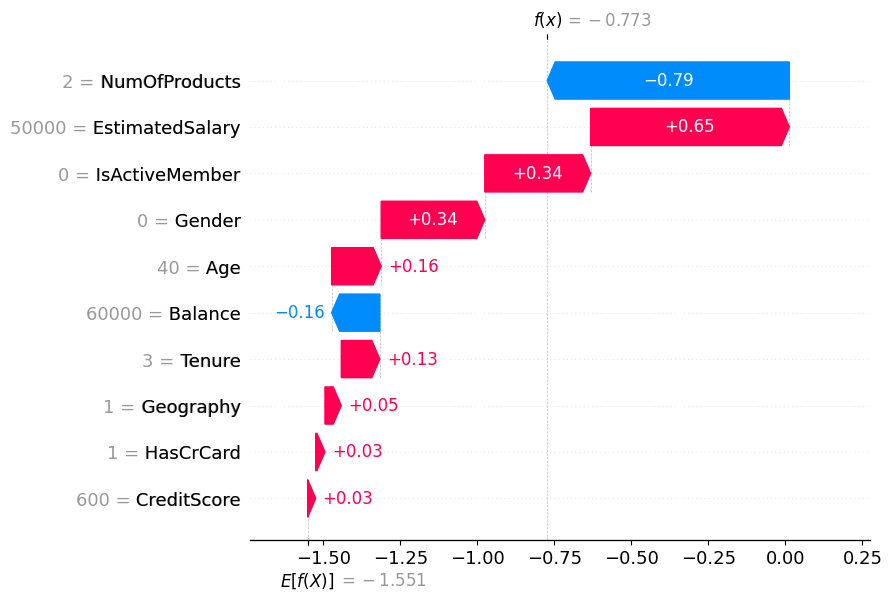

In [65]:


# 1. Define your new customer's values
new_customer_data = {
    "CreditScore": 600,
    "Geography": 1,
    "Gender":0,
    "Age":40,
    "Tenure":3,
    "Balance": 60000,
    "NumOfProducts":2,
    "HasCrCard": 1,
    "IsActiveMember":0,
    "EstimatedSalary": 50000
    }

# Convert to DataFrame with your exact model features
df_new = pd.DataFrame([new_customer_data])

# 2. Predict probability and final label
prob = model.predict_proba(df_new)[0, 1]
label = model.predict(df_new)[0]

print(f"Churn Probability: {prob * 100:.1f}%")
print(f"Predicted Label: {'Churn' if label == 1 else 'Stay'}")

# 3. Generate the individual SHAP explanation
# Ensure explainer was previously built: explainer = shap.TreeExplainer(model, model_output="probability")
shap_values_new = explainer(df_new)

# 4. Plot the local breakdown
shap.plots.waterfall(shap_values_new[0])


In [67]:
import joblib

joblib.dump(model, "Customer_churn_model.pkl")

encoders = {
    "Geography": geo_encoder,
    "Gender": gender_encoder
}

joblib.dump(encoders, "label_encoders.pkl")


['label_encoders.pkl']

In [ ]:
print(df.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [ ]:
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>
